# Time-Series-Aware Cross-Validation

## Overview

Standard k-fold CV randomly shuffles observations across folds. For time series, this creates **temporal leakage**: future observations appear in the training set, and the model learns from data it would not have had in production. This makes CV estimates unrealistically optimistic.

**Time-series CV strategies:**

| Strategy | Description | When to use |
|---|---|---|
| **Rolling origin** (expanding window) | Train on t=1…k, validate on t=k+1…k+h; expand training each fold | Standard; most commonly needed |
| **Rolling window** (sliding window) | Fixed-size training window slides forward | When stationarity is doubtful or older data is less relevant |
| **Single cutoff** | One train/test split at a fixed time point | Simplest; use when only one evaluation is needed |
| **Blocked CV** | Non-overlapping blocks treated as folds | Panel data; weakly dependent observations |

**The `lag` / `skip` parameters:**
- `lag`: gap between end of training set and start of validation — mimics real-world forecasting delay
- `skip`: folds to skip between successive training windows — reduces correlation between folds at the cost of fewer evaluation points

---

## Setup

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'rsample' was built under R version 4.4.3"
Warning message:
"package 'recipes' was built under R version 4.

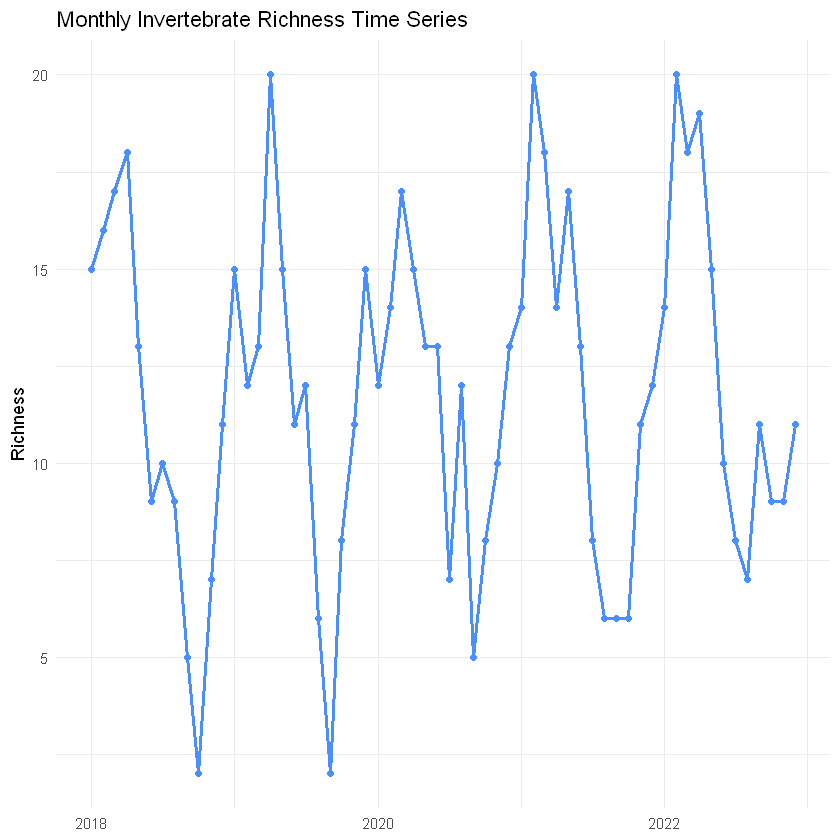

In [1]:
library(tidyverse)
library(ggplot2)
library(rsample)     # rolling_origin()
library(recipes)
library(parsnip)
library(workflows)
library(tune)
library(yardstick)
library(patchwork)

set.seed(42)

# ── Simulate a monthly ecological time series (5 years) ───────────────────────
n_months <- 60
ts_data <- tibble(
  month       = 1:n_months,
  date        = seq(as.Date("2018-01-01"), by="month", length.out=n_months),
  temperature = 12 + 8*sin(2*pi*month/12) + rnorm(n_months, 0, 1.5),
  rainfall    = pmax(rnorm(n_months, 60, 25), 0),
  nitrate     = 3 + 0.5*sin(2*pi*month/12 + pi) + rnorm(n_months, 0, 0.5)
) %>%
  mutate(
    # Target: invertebrate richness with trend + seasonality
    richness = round(
      15 + 0.05*month +                          # slight upward trend
      5*sin(2*pi*month/12) +                     # seasonality
      -2*nitrate + 0.02*rainfall +
      rnorm(n_months, 0, 2)
    )
  )

ggplot(ts_data, aes(x=date, y=richness)) +
  geom_line(color="#4a8fff", linewidth=0.9) +
  geom_point(size=1.5, color="#4a8fff") +
  labs(title="Monthly Invertebrate Richness Time Series",
       x=NULL, y="Richness") +
  theme_minimal()

---

## Rolling Origin CV (Expanding Window)

Rolling origin resamples: 6


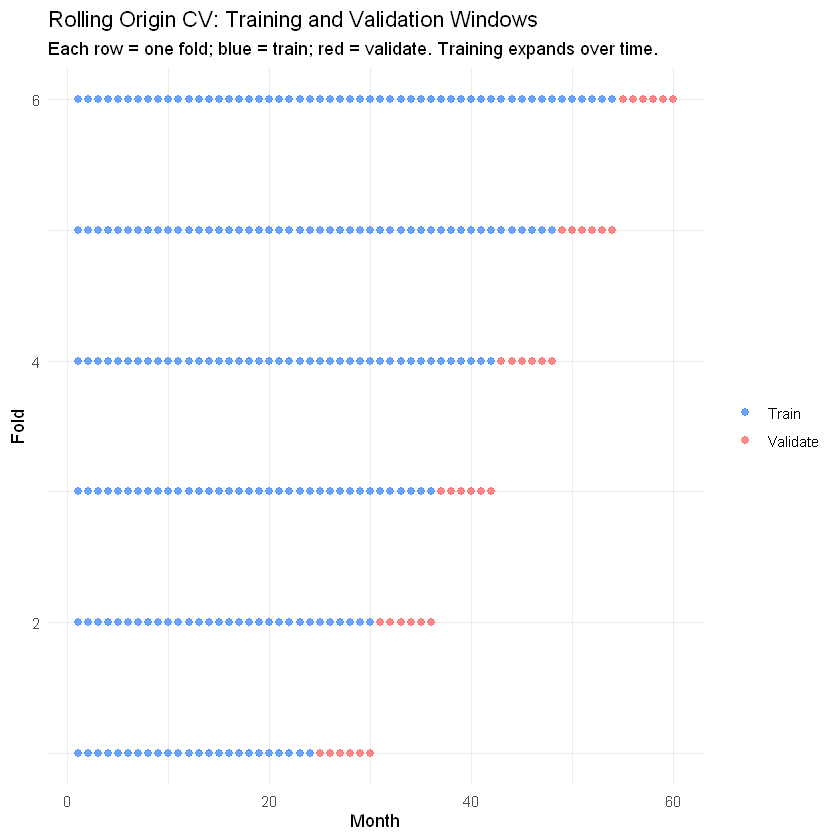

In [2]:
# ── Create rolling origin resamples ──────────────────────────────────────────
ro_splits <- rsample::rolling_origin(
  ts_data,
  initial    = 24,   # minimum 24 months (2 years) for training
  assess     = 6,    # validate on the next 6 months
  skip       = 5,    # skip 5 time points between successive origins
  cumulative = TRUE  # expanding window (set FALSE for sliding window)
)

cat(sprintf("Rolling origin resamples: %d\n", nrow(ro_splits)))

# ── Visualise the splits ──────────────────────────────────────────────────────
splits_viz <- map_dfr(seq_len(nrow(ro_splits)), function(i) {
  sp    <- ro_splits$splits[[i]]
  train <- rsample::analysis(sp)
  valid <- rsample::assessment(sp)
  bind_rows(
    tibble(split=i, month=train$month, role="Train"),
    tibble(split=i, month=valid$month, role="Validate")
  )
})

ggplot(splits_viz, aes(x=month, y=split, color=role)) +
  geom_point(size=2, alpha=0.8) +
  scale_color_manual(values=c(Train="#4a8fff", Validate="#ff6b6b")) +
  labs(title="Rolling Origin CV: Training and Validation Windows",
       subtitle="Each row = one fold; blue = train; red = validate. Training expands over time.",
       x="Month", y="Fold", color=NULL) +
  theme_minimal()

---

## Fitting a Model with Rolling Origin CV

In [3]:
# Regression model: richness ~ temperature + rainfall + nitrate + lagged richness
ts_data_lagged <- ts_data %>%
  mutate(
    richness_lag1 = lag(richness, 1),
    richness_lag2 = lag(richness, 2)
  ) %>%
  drop_na()

ro_lag_splits <- rsample::rolling_origin(
  ts_data_lagged,
  initial=22, assess=6, skip=5, cumulative=TRUE
)

rec <- recipe(richness ~ temperature + rainfall + nitrate + richness_lag1 + richness_lag2,
              data=ts_data_lagged) %>%
  step_normalize(all_numeric_predictors())

lm_spec <- linear_reg() %>% set_engine("lm")
wf      <- workflow() %>% add_recipe(rec) %>% add_model(lm_spec)

cv_results <- tune::fit_resamples(
  wf,
  resamples = ro_lag_splits,
  metrics   = metric_set(rmse, rsq, mae)
)

tune::collect_metrics(cv_results)

.metric,.estimator,mean,n,std_err,.config
<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
mae,standard,1.8538702,6,0.2107358,pre0_mod0_post0
rmse,standard,2.3088677,6,0.2893464,pre0_mod0_post0
rsq,standard,0.5121138,6,0.1174956,pre0_mod0_post0


---

## Demonstrating Temporal Leakage

Random k-fold CV RMSE (LEAKY):    2.349
Rolling origin CV RMSE (CORRECT): 2.309

Random CV is typically lower — temporal leakage makes it optimistic.


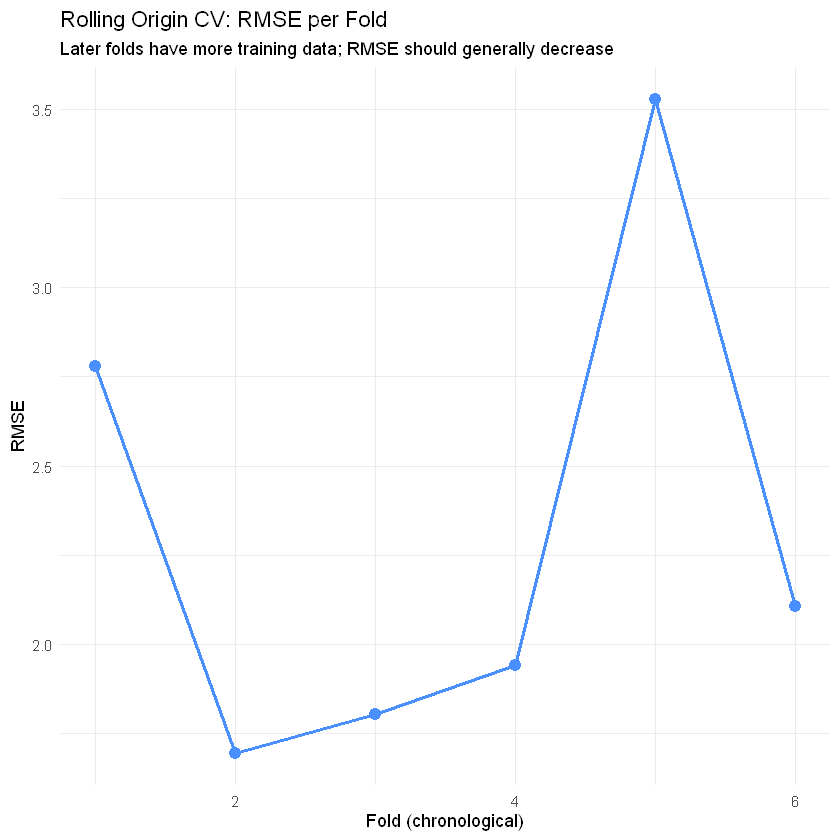

In [4]:
# Compare: random k-fold (leaky) vs. rolling origin (correct)

random_splits <- rsample::vfold_cv(ts_data_lagged, v=5)

rmse_random <- tune::fit_resamples(wf, random_splits,
                                   metrics=metric_set(rmse)) %>%
  collect_metrics() %>% pull(mean)

rmse_rolling <- tune::fit_resamples(wf, ro_lag_splits,
                                    metrics=metric_set(rmse)) %>%
  collect_metrics() %>% pull(mean)

cat(sprintf("Random k-fold CV RMSE (LEAKY):    %.3f\n", rmse_random))
cat(sprintf("Rolling origin CV RMSE (CORRECT): %.3f\n", rmse_rolling))
cat("\nRandom CV is typically lower — temporal leakage makes it optimistic.\n")

# Per-fold RMSE for rolling origin — shows performance as training grows
tune::collect_metrics(cv_results, summarize=FALSE) %>%
  filter(.metric=="rmse") %>%
  mutate(fold=as.integer(str_extract(id, "[0-9]+"))) %>%
  ggplot(aes(x=fold, y=.estimate)) +
  geom_line(color="#4a8fff", linewidth=1) +
  geom_point(size=3, color="#4a8fff") +
  labs(title="Rolling Origin CV: RMSE per Fold",
       subtitle="Later folds have more training data; RMSE should generally decrease",
       x="Fold (chronological)", y="RMSE") +
  theme_minimal()

---

## Sliding Window vs. Expanding Window

In [5]:
# Sliding window: fixed training size; older data is discarded
# Use when the relationship is non-stationary or older data hurts performance

sliding_splits <- rsample::rolling_origin(
  ts_data_lagged,
  initial    = 22,
  assess     = 6,
  skip       = 5,
  cumulative = FALSE   # sliding window: training size stays fixed at 22
)

rmse_sliding <- tune::fit_resamples(wf, sliding_splits,
                                    metrics=metric_set(rmse)) %>%
  collect_metrics() %>% pull(mean)

cat(sprintf("Expanding window RMSE: %.3f\n", rmse_rolling))
cat(sprintf("Sliding window RMSE:   %.3f\n", rmse_sliding))
cat("\nIf sliding < expanding: older data hurts (non-stationary or structural break)\n")
cat("If expanding < sliding: more data always helps (stationary process)\n")

Expanding window RMSE: 2.309
Sliding window RMSE:   2.092

If sliding < expanding: older data hurts (non-stationary or structural break)
If expanding < sliding: more data always helps (stationary process)


---

## Common Pitfalls

**1. Using random k-fold CV on time series data**  
This is the most common error in time series model evaluation. Future observations appear in training folds, allowing the model to implicitly learn future patterns. CV estimates are unrealistically optimistic. Always use `rolling_origin()` or `initial_time_split()` for temporal data.

**2. Not including a `lag` gap between training end and validation start**  
If a model is intended to forecast h steps ahead, the validation fold should start h time steps after the training fold ends. Without a lag, the validation immediately follows training — which is too optimistic if the real forecasting horizon is longer.

**3. Creating lagged features before splitting into folds**  
Lagged predictors computed on the full dataset before creating folds can leak future information into the training window if lags span the training/validation boundary. Create lag features inside each fold using `step_lag()` in a recipe, or use `ts_data %>% lag()` only within the analysis() portion of each split.

**4. Treating all folds as equally informative**  
The first few rolling origin folds have very small training sets and may produce unstable estimates. Weight later folds more heavily or require a minimum training window size before including a fold in performance summaries.

**5. Using rolling origin CV for panel data without blocking by group**  
If multiple sites are measured over the same time period, `rolling_origin()` treats all sites as a single ordered series. Sites measured in the validation period but in the same training rows as training-period observations will leak. Consider `group_vfold_cv()` with time-ordered groups or a blocked design.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*